<img alt="logo" height="100" src="img/logo.jpeg" width="100"/>   

# <a id='toc1_'></a>[REGRESIÓN LINEAL](#toc0_)
### <a id='toc1_1_1_'></a>[Definición](#toc0_)
Hay diferentes tipos de regresión lineal, y la más sencilla y práctica para aprender machine learning es la **regresión lineal simple**. Esta consta de una variable independiente y otra variable dependiente, pudiendo existir una relación entre ambas variables que hará que, a medida que aumenta el valor de una la otra lo haga proporcionalmente.  

En estadística, la **regresión lineal simple** (o el ajuste lineal) es un modelo matemático utilizado para encontrar la relación de dependencia entre una variable dependiente (y) y otra independiente (X). En el caso de la regresión lineal múltiple buscaría la relación entre una variable dependiente y 'm' variables independientes.   


 <img width="460" height="300" src="img/linealregresion.png" >   


**Tabla de contenidos**<a id='toc0_'></a>    
- [REGRESIÓN LINEAL](#toc1_)    
    - [Definición](#toc1_1_1_) 
    - [Aproximación matemática](#toc1_1_)   
    - [Desarrollo de un modelo de regresión lineal en Python](#toc1_1_2_)    
    - [PASO 1 - GENERACIÓN DEL DATAFRAME (PANDAS) CON LOS DATOS A ANALIZAR](#toc1_1_3_)    
    - [PASO 2 - ANÁLISIS INICIAL DEL CONTENIDO DEL DATAFRAME](#toc1_1_4_)    
    - [PASO 3 - PARTICIONADO DE DATOS PARA GENERAR CONJUNTOS TRAIN Y TEST](#toc1_1_5_)    
    - [PASO 4 - CREACIÓN DEL MODELO DE REGRESIÓN LINEAL SIMPLE](#toc1_1_6_)    
      - [Predicción](#toc1_1_6_1_)    
      - [Visualización de coeficientes mínimos cuadrados W1 y W0](#toc1_1_6_2_)    
    - [Error cuadrático medio - MSE](#toc1_1_7_)    
    - [Coeficientes de determinación (R2)](#toc1_1_8_)    
    - [Graficado](#toc1_1_9_)    
      - [Ploteado de la gráfica de regresión lineal simple](#toc1_1_9_1_)    
      - [Ploteado de la gráfica de relación entre variables del conjunto de datos](#toc1_1_9_2_)    
      - [Ploteado de la gráfica de datos de entrenamiento](#toc1_1_9_3_)    
  - [REGRESIÓN LINEAL (Ejemplo 2)](#toc1_2_)    
      - [Importamos librerías.](#toc1_2_1_1_)    
    - [Generación del dataset simulado](#toc1_2_2_)    
    - [División del dataset en entrenamiento y test](#toc1_2_3_)    
    - [Creación y entrenamiento del modelo de regresión lineal multivariable](#toc1_2_4_)    
    - [Evaluación del modelo con el conjunto de test](#toc1_2_5_)    
    - [Raíz del Error Cuadrático Medio (RMSE)](#toc1_2_6_)    
    - [Coeficiente Determinación (R2)](#toc1_2_7_)    
    - [Análisis evaluativo del modelo](#toc1_2_8_)    
    - [Realización de una predicción sobre datos ficticios](#toc1_2_9_)    
    - [Visualización](#toc1_2_10_)     
  - [REGRESIÓN LINEAL - (Ejemplo 3)](#toc1_4_)    
    - [Análisis evaluativo del modelo](#toc1_4_1_)    
  - [EJERCICIO PRÁCTICO](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Aproximación matemática.](#toc01)
### Funciones lineales (y = mx + b)
Una función lineal describe cómo una variable cambia respecto a otra. En IA, se usan en **regresión lineal** para predecir valores numéricos.

📌 **Ejemplo** (criptomonedas): supongamos que el precio de un token aumenta 2 € cada día y hoy vale 100 €. La fórmula sería:
\[
precio = 2 	* días + 100
\]

In [1]:
# Predicción de precio de un token
import numpy as np
dias = np.array([0, 1, 2, 3, 4, 5])
precio = 2 * dias + 100
print("Precios previstos:", precio)

Precios previstos: [100 102 104 106 108 110]


💡 **Ejercicio**:  
Un streamer gana 5 nuevos suscriptores por día y empieza con 200.  
Crea la función lineal y calcula cuántos suscriptores tendrá al cabo de 10 días.

In [5]:
dias = np.array([0,1,2,3,4,5,6,7,8,9])
inicial = 200
suscriptores = 5 * dias + inicial
print('Suscriptores al cabo de 10 días:', suscriptores[len(suscriptores)-1])


Suscriptores al cabo de 10 días: 245


### Pendiente e intercepto
- **Pendiente (m)**: cuánto cambia la variable dependiente cuando la independiente aumenta en 1 unidad.
- **Intercepto (b)**: valor cuando la variable independiente es 0.

📌 **Ejemplo** (salud): si cada hora extra de sueño reduce el estrés en 3 puntos y el nivel de estrés sin dormir es 80, la pendiente es -3 y el intercepto es 80.

In [6]:
# Cálculo de pendiente e intercepto a partir de datos
horas_sueno = np.array([4, 5, 6, 7, 8])  # Con 4 horas de sueño, el estrés es 68 (80 - 4*3 = 68)
estres = np.array([68, 65, 62, 59, 56])
# polyfit deveuelve un array de coeficientes siendo el primer elemento la pendiente y el segundo el intercepto. 
# 1 indica que es una regresión lineal (grado 1)
m, b = np.polyfit(horas_sueno, estres, 1) 
print("Pendiente:", m)
print("Intercepto:", b)

Pendiente: -3.0000000000000036
Intercepto: 80.00000000000003


💡 **Ejercicio**:  
Imagina que tienes datos de horas de entrenamiento y calorías quemadas.  
Crea arrays y usa `np.polyfit` para obtener la pendiente e intercepto, siguiendo el ejemplo anterior.

In [18]:
horas_entrenamiento = [2,4,5,6,8]
calorias_quemadas = [600, 1200,1500,1800,2400]
m, b = np.polyfit(horas_entrenamiento, calorias_quemadas, 1)
print('Pendiente:', m)
print('Intercepto:' , b)

Pendiente: 300.0
Intercepto: 1.2761942824416385e-13


### <a id='toc1_1_2_'></a>[Desarrollo de un modelo de regresión lineal en Python](#toc0_)

Se va a ir generando el código de la regresión lineal simple paso a paso para una mejor compresión 

### <a id='toc1_1_3_'></a>[PASO 1 - GENERACIÓN DEL DATAFRAME (PANDAS) CON LOS DATOS A ANALIZAR](#toc0_)

In [19]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ------------------------------------
# Crear dataframe con los datos de facturación de clientes
data = {'customer_id': [1, 2, 3, 4, 5],
        'billing_amount': [100, 200, 150, 300, 250],
        'sales': [2, 4, 3, 6, 5]
}
clients = pd.DataFrame(data)

### <a id='toc1_1_4_'></a>[PASO 2 - ANÁLISIS INICIAL DEL CONTENIDO DEL DATAFRAME](#toc0_)

Se muestran, a modo de comprobación,  los datos almacenados en el dataframe

In [20]:
print(clients)

   customer_id  billing_amount  sales
0            1             100      2
1            2             200      4
2            3             150      3
3            4             300      6
4            5             250      5


In [21]:
clients

,customer_id,billing_amount,sales
0,1,100,2
1,2,200,4
2,3,150,3
3,4,300,6
4,5,250,5


Se comprueban los tipos de datos contenidos en el conjunto de datos y las dimensiones dataframe

In [22]:
print(clients.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     5 non-null      int64
 1   billing_amount  5 non-null      int64
 2   sales           5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes
None


Se muestra la información sobre las dimensiones del dataframe

In [23]:
print(clients.shape)

(5, 3)


### <a id='toc1_1_5_'></a>[PASO 3 - PARTICIONADO DE DATOS PARA GENERAR CONJUNTOS TRAIN Y TEST](#toc0_)   

#### ¿Porqué dividimos los datos en los conjuntos de "train" y "test"?   

Los algoritmos de Machine Learning aprenden de los datos con los que los entrenamos. A partir de ellos, intentan encontrar o inferir el patrón que les permita predecir el resultado para un nuevo caso. Pero, para poder calibrar si un modelo funciona, necesitaremos probarlo con un conjunto de datos diferente. Por ello, en todo proceso de aprendizaje automático, los datos de trabajo se dividen en dos partes: **datos de entrenamiento(train)** y **datos de prueba(test)**.   

Los *datos de entrenamiento o "training data"* son los datos que usamos para **entrenar un modelo**. La calidad de nuestro modelo de aprendizaje automático va a ser directamente proporcional a la calidad de los datos. Por ello las labores de limpieza, depuración o "data wrangling" consumen un porcentaje importante del tiempo de los científicos de datos.   

Los *datos de prueba o "testing data"* son los datos que nos “reservamos” para **comprobar** si el modelo que hemos generado a partir de los datos de entrenamiento “funciona”. Es decir, si las respuestas predichas por el modelo para un caso totalmente nuevo son acertadas o no.

Es importante que el conjunto de datos de prueba tenga un volumen suficiente como para generar resultados estadísticamente significativos, y a la vez, que sea representativo del conjunto de datos global.

Normalmente el conjunto de datos se suele repartir en un **70% de datos de entrenamiento** y un **30% de datos de test** (también es habitual la proporción *80-20*), pero se puede variar la proporción según el caso. Lo importante es ser siempre conscientes de que hay que evitar el sobreajuste u “overfitting”.   

En el siguiente bloque de código realizamos la partición de nuestro dataset. Al no indicar valor alguno para el parámetro ```train_size``` ni para el parámetro ```test_size```, el valor por defecto es de ```test_size = 0.25```. Es decir: 75-25. (Más info sobre la función [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html))

In [24]:
# el parametro random_state asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(clients['billing_amount'], clients['sales'], random_state=20) 

Con esta línea de código indicamos que se cree, genere y divida los datos de cliente en varios conjuntos de datos de entrenamiento y prueba:  

- Datos de entrada: 'billing_amount', que es la facturación de los clientes.
- Variable independiente: 'sales', importe de ventas.
- random_state: se genera una semilla aleatoria para dividir los datos de forma consistente cada vez que ejecutamos el código.
- X_train: datos de entrada del conjunto de entrenamiento. Información que se usa para entrenar el modelo.
- X_test: datos de entrada del conjunto de prueba. Información que se usa para testear el rendimiento del modelo ya entrenado.
- y_train: datos de salida del conjjunto de entrenamiento. Información objetivo que se usa para entrenar el modelo.
- y_test: datos de salida del conjunto de prueba. Información objetivo que se usa para testear el rendimiento del modelo ya entrenado.
  
Realizar esta partición es crucial para evaluar el rendimiento del modelo entrenado.

### <a id='toc1_1_6_'></a>[PASO 4 - CREACIÓN DEL MODELO DE REGRESIÓN LINEAL SIMPLE](#toc0_)

### Formulación matemática de la Regresión Lineal
Para resolver el problema de la Regresión Lineal es necesario representar matemáticamente las ideas de “línea recta” y “mejor ajuste”, comentadas a continuación.

#### Ecuación de una línea recta

La relación lineal entre dos variables $x$ (variable independiente) e $y$ (variable dependiente) se representa matemáticamente a través de la ecuación:
$$
y = \omega x + b
$$

donde $\omega$ representa la pendiente (inclinación) de la línea recta y $b$ es la intersección con el eje y.

Así, el objetivo de la Regresión Lineal es encontrar los valores más adecuados de $\omega$ y de $b$ que representen de la mejor forma posible la relación entre las variables $x$ e $y$.

Para encontrar esta “mejor representación” debemos definir de forma adecuada algún tipo de métrica que nos permita cuantificar qué tan precisa es la Regresión Lineal que estamos realizando.    
Esta métrica se conoce como **función de pérdida** (o de costo) en el ámbito Machine Learning, y permite medir la diferencia existente entre los datos reales ($y$) y los datos obtenidos tras realizar la Regresión Lineal ($ŷ$).   

In [25]:
lr = LinearRegression().fit(X_train.values.reshape(-1, 1), y_train)

#### <a id='toc1_1_6_1_'></a>[Predicción](#toc0_)
Usamos el conjunto de test para realizar la predicción usando el modelo entrenado.

In [28]:
y_pred = lr.predict(X_test.values.reshape(-1, 1))

#### NOTA:    

**X_test** contiene los datos de entrada del conjunto de prueba. Con **"reshape(-1,1)"** o con **".values.reshape(-1, 1)"** se pretende redimensionar la matriz a las dimensiones que requiere el modelo LinearRegression() de ***SciKit-learn***.    

La mayoría de los modelos de ***Scikit-learn***, incluido LinearRegression, están diseñados para trabajar con una tabla de datos (o una matriz) como entrada. Piensan en los datos de entrada (las variables predictoras, X) como una estructura de dos dimensiones:

- **Filas**: Cada una representa una muestra u observación (por ejemplo, un cliente, una casa, un día).
- **Columnas**: Cada una representa una característica o variable (por ejemplo, la edad del cliente, el tamaño de la casa, la temperatura del día).   

La librería, como se comenta, está diseñada para trabajar con un formato de datos ```(n_samples, n_features)```, es decir, ```(número de muestras, número de características)```. Esto permite que el mismo código funcione tanto para una regresión con una sola variable como para una con múltiples variables.   

*X_train* y *X_test* son objetos de tipo Serie de Pandas. Una Serie es una estructura unidimensional (1D), similar a una lista. Al convertirla a un array de NumPy se obtiene un array con una forma **(n,)**.  

La función ```reshape(-1,1)``` transforma el array 1D en un array 2D. El *1* indica que se quiere que el nuevo array tenga una columna (porque solo existe una característica). El *-1* es un comodín que le dice a NumPy: "calcula tú mismo el número de filas necesarias".

Por tanto, ```reshape(-1, 1)``` convierte los datos de una lista de valores a una tabla con una sola columna, que es el formato que ***Scikit-learn*** necesita para entender que existen muchas muestras (filas) de una sola característica (columna).

#### <a id='toc1_1_6_2_'></a>[Visualización de coeficientes mínimos cuadrados W1 y W0](#toc0_)

Los **coeficientes mínimos cuadrados** de una Regresión Lineal son los valores de los parámetros (*pendiente* e *intercepto*) de la recta que ***mejor se ajusta*** a un conjunto de datos al minimizar la suma de los cuadrados de las distancias verticales entre los puntos de datos observados y los puntos predichos por la recta.    
Este método, conocido como Mínimos Cuadrados Ordinarios (MCO), busca la *recta de regresión que minimiza el error cuadrático*, haciendo que las predicciones sean lo más cercanas posible a los valores reales. 

In [27]:
print("Coeficiente w1:", lr.coef_) # pendiente. Al ser una regresión lineal simple, solo hay un coeficiente. En un caso de regresión múltiple habría varios coeficientes.
print("Coeficiente w0:", lr.intercept_)

Coeficiente w1: [0.02]
Coeficiente w0: 4.440892098500626e-16


### <a id='toc1_1_7_'></a>[Error cuadrático medio - MSE](#toc0_)
Existen diferentes formas de definir matemáticamente la pérdida, pero la más usada es a través del **error cuadrático medio (ECM/MSE)**, definido de la siguiente manera:

$$
MSE/ECM =\frac{1}{N}\sum_{i = 1}^{N}{(y_i-ŷ_i)}^2
$$
donde *N* es el número total de datos que se tienen originalmente, $y_i$ e $ŷ_i$ son cada uno de los datos originales y los obtenidos a partir de la regresión, y la resta $y_i-ŷ_i$ se eleva al cuadrado para que todas las diferencias que están en la sumatoria sean positivas y no se cancelen entre sí. Esta resta se ilustra en la siguiente figura:

<img width="700" height="600" src="img/ecm.png" >   

Así pues, el **error cuadrático medio (ECM o MSE)** mide la diferencia al cuadrado entre el valor real y el valor predicho en el total de predicciones del modelo de Machine Learning utilizado, mostrando las diferencias más elevadas.     

En estadística, el error cuadrático medio es un **estimador que mide el promedio de errores al cuadrado**, es decir, la diferencia entre el estimador y lo que se estima. Es un parámetro perfecto para medir la cantidad de error entre dos conjuntos de datos. Una explicación sencilla es decir que *"compara el valor predicho con el valor conocido"*, dando como resultado un coeficiente de error.   

Consideraciones

- MSE nunca será negativo ya que los errores se elevan al cuadrado
- El valor del error varía de cero a infinito
- MSE aumenta exponencialmente con un aumento en el error
- Un buen modelo tendrá un valor MSE más cercano a cero. 

In [29]:
print("MSE: ",mean_squared_error(y_test, y_pred))

MSE:  0.0


Por tanto, un valor bajo de MSE supone un muy buen ajuste del modelo.

### <a id='toc1_1_8_'></a>[Coeficientes de determinación (R2)](#toc0_)

El coeficiente de determinación de entrenamiento y de pruebas debe ser parecido. Cuando encontramos que ambos valores tienen una diferencia grande suele significar que el modelo está mal ajustado. El coeficiente de determinación (${R}^2$) (R al cuadrado) se utiliza en estadística para cuantificar cómo de cerca están los puntos en la recta de regresión. Es decir, indica en qué medida el cambio en una variable (por ejemplo, las notas de un examen) puede explicarse por los cambios en otra (por ejemplo, las horas de estudio). De esta forma, será posible comprender en qué medida el modelo «se ajusta» a los datos.

Los valores esperados para este coeficiente están dentro del rango entre 0 y 1, siendo 0 el valor cuando el modelo NO explica NINGUNA VARIABILIDAD en los datos y 1 cuando el modelo explica TODA LA VARIABILIDAD de los datos.    
Los valores más cercanos a 1, por tanto, significan un **mejor ajuste**, indicando que el modelo en cuestión está captando mejor el patrón de datos.

In [30]:
print("Valor del coeficiente de determinación del conjunto de entrenamiento:", round (lr.score(X_train.values.reshape(-1, 1), y_train), 3))
print("Valor del coeficiente de determinación del conjunto de prueba:", round (lr.score(X_test.values.reshape(-1, 1), y_test), 3))

Valor del coeficiente de determinación del conjunto de entrenamiento: 1.0
Valor del coeficiente de determinación del conjunto de prueba: 1.0


### <a id='toc1_1_9_'></a>[Graficado](#toc0_)

#### <a id='toc1_1_9_1_'></a>[Ploteado de la gráfica de regresión lineal simple](#toc0_)

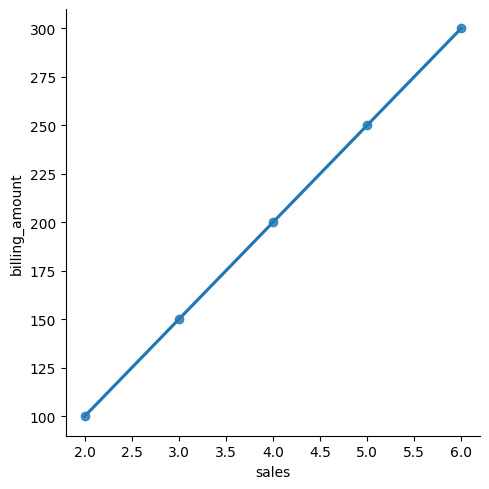

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear un gráfico de regresión lineal usando seaborn
sns.lmplot(x='sales', y='billing_amount', data=clients)
# Mostrar gráfico
plt.show()

#### <a id='toc1_1_9_2_'></a>[Ploteado de la gráfica de relación entre variables del conjunto de datos](#toc0_)

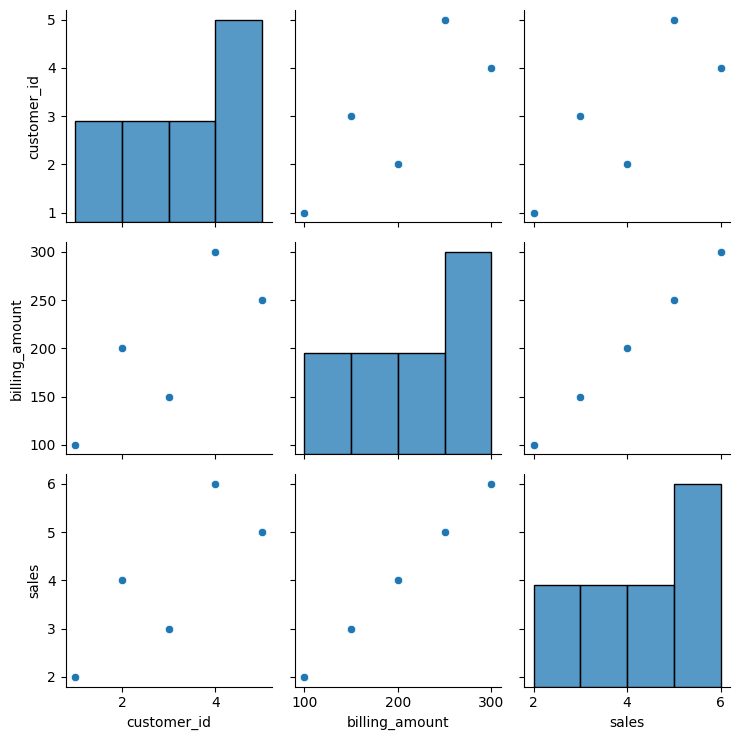

In [32]:
# Gráfico de relación entre variables del conjunto de datos.
sns.pairplot(clients, height=2.5)
plt.tight_layout()
plt.show()

#### <a id='toc1_1_9_3_'></a>[Ploteado de la gráfica de datos de entrenamiento](#toc0_)

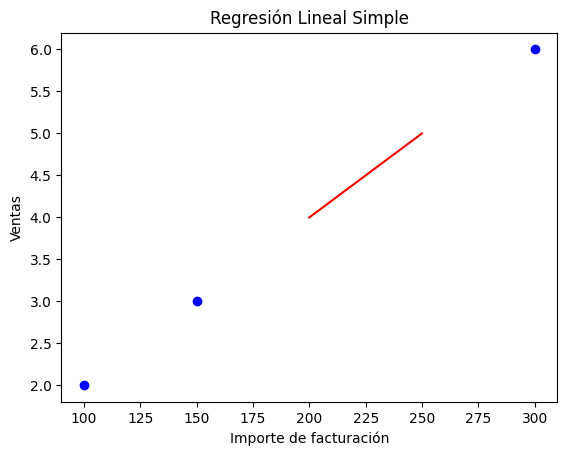

In [33]:
# Graficando los datos de entrenamiento
plt.scatter(X_train, y_train, color='blue')

# Grafica de la regresión lineal con datos de la predicción
plt.plot(X_test, y_pred, color='red')
plt.title('Regresión Lineal Simple')
plt.xlabel('Importe de facturación')
plt.ylabel('Ventas')
plt.show()

Con esto ya tenemos creada una regresión lineal simple con Python.

Esta última gráfica, muestra los puntos de los datos de entrenamiento en color azul y la línea de regresión lineal en rojo.
La línea de regresión lineal representa el modelo que se ha entrenado para hacer predicciones.

La interpretación de la gráfica indica que, **a medida que el número de ventas se incrementa, el importe de facturación también aumenta**. Esto se ve reflejado en la pendiente positiva de la línea de regresión. Sin embargo, esta es una interpretación basada en una sola variable, si se utilizaran más variables se podría tener una interpretación más precisa y completa.

## <a id='toc1_2_'></a>[REGRESIÓN LINEAL (Ejemplo 2)](#toc0_)

#### <a id='toc1_2_1_1_'></a>[Importamos librerías.](#toc0_)

In [17]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### <a id='toc1_2_2_'></a>[Generación del dataset simulado](#toc0_)
Queremos predecir el precio de una vivienda (target) a partir de dos variables:
 - Tamaño en metros cuadrados (X1)
 - Número de habitaciones (X2)

In [18]:

np.random.seed(42)  # para reproducibilidad

# Generamos 200 muestras
n_samples = 200
X1 = np.random.normal(loc=100, scale=20, size=n_samples)  # Tamaño en m². El parametro loc es la media y scale la desviación estándar
X2 = np.random.randint(1, 6, size=n_samples)  # Entre 1 y 5 habitaciones

Definimos una relación lineal con cierto ruido.  
Coeficientes: 2000 €/m² y 10000 €/habitación, y un intercepto de 50000 €

In [19]:
error = np.random.normal(loc=0, scale=10000, size=n_samples)  # ruido aleatorio para simular variabilidad en los precios
y = 2000 * X1 + 10000 * X2 + 50000 + error

Combinamos las variables predictoras en un DataFrame

In [20]:
data = pd.DataFrame({
    'Tamaño_m2': X1,
    'Num_Habitaciones': X2,
    'Precio': y
})

In [21]:
print(data.head())

    Tamaño_m2  Num_Habitaciones         Precio
0  109.934283                 2  301917.795338
1   97.234714                 2  252502.823261
2  112.953771                 1  293614.324819
3  130.460597                 1  327591.755291
4   95.316933                 1  243642.399230


### <a id='toc1_2_3_'></a>[División del dataset en entrenamiento y test](#toc0_)

In [22]:
X = data[['Tamaño_m2', 'Num_Habitaciones']] # Dos características predictoras o variables independientes
y = data['Precio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### <a id='toc1_2_4_'></a>[Creación y entrenamiento del modelo de regresión lineal multivariable](#toc0_)

In [23]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Imprimimos los coeficientes y el intercepto obtenidos

In [24]:

print("Intercepto (b₀):", modelo.intercept_)
print("Coeficientes (b₁, b₂):", modelo.coef_)

Intercepto (b₀): 57937.81951953238
Coeficientes (b₁, b₂): [1934.71153978 9749.68263101]


### <a id='toc1_2_5_'></a>[Evaluación del modelo con el conjunto de test](#toc0_)

In [25]:

y_pred = modelo.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nEvaluación del modelo:")
print("Error Cuadrático Medio (MSE):", mse)
print("Raíz del Error Cuadrático Medio (RMSE):", np.sqrt(mse))
print("Coeficiente de determinación (R²):", r2)


Evaluación del modelo:
Error Cuadrático Medio (MSE): 91368642.96252187
Raíz del Error Cuadrático Medio (RMSE): 9558.69462649173
Coeficiente de determinación (R²): 0.9423903718304878


### <a id='toc1_2_6_'></a>[Raíz del Error Cuadrático Medio (RMSE)](#toc0_)

Se calcula tomando la raíz cuadrada de MSE. Es conocida también como la desviación cuadrática media. Mide la magnitud promedio de los errores y se ocupa de las desviaciones del valor real. Es una estadística imperfecta para la evaluación, pero es muy común.    
Se puede tomar el RMSE como la "distancia promedio" entre los puntos de información reales y la línea (o plano) que el modelo "ha dibujado" para representarlos.
Si se considera el penalizar errores grandes, no es una mala opción. Es una excelente opción para una métrica de pérdida cuando se ajustan los HiperParametros o se entrena por bloque una red neuronal profunda.

Consideraciones:

- RMSE con valor 0 indica que el modelo tiene un ajuste perfecto.
- Cuanto menor sea el RMSE, mejor será el modelo y sus predicciones.
- Se expresa en las mismas unidades que la variable que se intenta predecir. Si se quiere predecir el precio de una vivienda en euros, un RMSE de 5.000 significa que, de media, el error de predicción del modelo es de 5.000 €.

In [31]:
print("Raíz del Error Cuadrático Medio (RMSE):", np.sqrt(mse))

Raíz del Error Cuadrático Medio (RMSE): 9558.694626491739


### <a id='toc1_2_7_'></a>[Coeficiente Determinación (R2)](#toc0_)

También conocido como prueba de bondad de ajuste, y como se ha visto anteriormente, es una métrica que indica el rendimiento del modelo, explicando qué **proporción de variabilidad** de la variable dependiente (o variable objetivo) puede ser explicada por la variable (o variables) independiente.

En otras palabras, representa la ***"fuerza del ajuste"*** de que tan bien se ajusta el modelo a las observaciones reales que tenemos, sin embargo, no dice nada sobre el modelo en sí, no indica si es bueno malo, si los datos están sesgados o si hemos elegido el método correcto.

Consideraciones:

El valor de R² varía de 0 a 1; los valores más altos indican un ajuste fuerte y los valores más bajos indican un ajuste débil.

- R² < 0,5 → Ajuste débil. El modelo no explica nada de la variabilidad de los datos. Básicamente, no es mejor que simplemente usar el promedio de la variable objetivo como predicción.
- 0,5 ≤ R² ≤ 0,8 → Ajuste moderado. 
- R² > 0,8 → Ajuste fuerte. El modelo explica el 80% de la variabilidad de la variable objetivo. El 20% restante se debe a otros factores (variables que no incluiste, aleatoriedad, etc.).
- R² = 1 → Ajuste perfecto. El modelo explica toda la variabilidad de los datos. Esto significa que las predicciones son perfectas. En la práctica, esto es muy raro y a menudo es señal de un problema (como el sobreajuste o overfitting).



In [32]:
print("Coeficiente de determinación (R²):", r2)

Coeficiente de determinación (R²): 0.9423903718304877


### <a id='toc1_2_8_'></a>[Análisis evaluativo del modelo](#toc0_)
Dado que la variable dependiente es un **precio** y se encuentra en el rango de **cientos de miles**, podemos interpretar los resultados de la siguiente manera:

1. **R² (0.9423)**  
   - Indica que aproximadamente el **94.23%** de la variabilidad en los precios está siendo explicada por el modelo, lo cual es muy elevado y sugiere que el modelo capta gran parte de los factores que inciden en el precio.

2. **MSE (~ 91,368,642.96) y RMSE (~ 9,558.69)**  
   - El **RMSE** se interpreta en las mismas unidades de la variable objetivo: aquí, en términos monetarios.  
   - Si los precios promedio se ubican, por ejemplo, alrededor de 200,000 o 300,000, un error de unos 9,558 podría representar un error relativo del **3% al 5%** aproximadamente, lo cual puede considerarse razonable o incluso bueno en muchos contextos de predicción de precios.  
   - Conviene siempre compararlo con el rango real de precios. Si la mayoría de las propiedades se sitúan en 250,000 - 350,000, un error promedio de 9,558 puede ser un margen aceptable.  

**Interpretación general del modelo**  
   - El **alto valor de R²** (0.94) y un **RMSE moderado** en el contexto de precios de cientos de miles de unidades monetarias sugieren que el modelo está funcionando de manera adecuada.  
   - Sería prudente, además, la **distribución de errores** (por ejemplo, si hay viviendas muy costosas o muy baratas que elevan el error de manera significativa o si hay heterocedasticidad (mayor dispersión para valores mayores y menor dispersión para valores menores de la variable objetivo/dependiente)) puede ayudar a detectar posibles problemas en segmentos específicos del rango de precios.  

En conclusión, dada la escala de cientos de miles, un **RMSE de aproximadamente 9,558** parece aceptable y, combinado con un **R² de 0.94**, indica que el modelo logra explicar la mayor parte de la variación en el precio y lo hace con un margen de error relativamente bajo en términos porcentuales. 

### <a id='toc1_2_9_'></a>[Realización de una predicción sobre datos ficticios](#toc0_)
Supongamos una vivienda de 120 m² y 3 habitaciones

In [33]:
nuevos_datos = np.array([[120, 3]])
prediccion = modelo.predict(nuevos_datos)
print("\nPredicción para una vivienda de 120 m² y 3 habitaciones:", prediccion[0])


Predicción para una vivienda de 120 m² y 3 habitaciones: 319352.252185602


### <a id='toc1_2_10_'></a>[Visualización](#toc0_)
Aunque la regresión es multivariable y la visualización completa es compleja,
graficaremos la relación real vs. predicha en el conjunto de test.

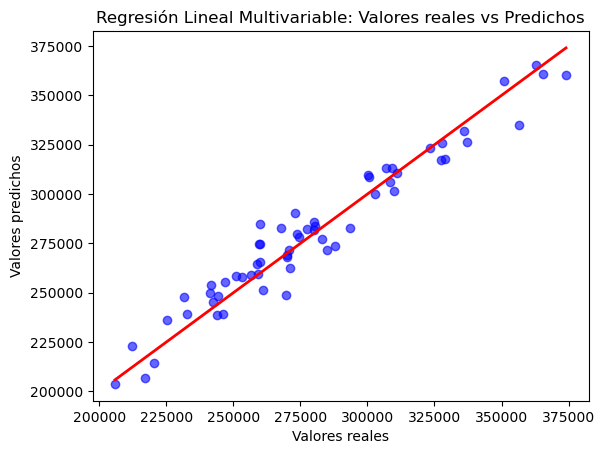

In [34]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Regresión Lineal Multivariable: Valores reales vs Predichos')
plt.show()

## <a id='toc1_4_'></a>[REGRESIÓN LINEAL - (Ejemplo 3)](#toc0_)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

In [36]:
from sklearn import datasets

In [41]:
housing_dataset =  pd.read_csv('/home/jordi/Documentos/Ribera/Curso_25_26/CEIABD/CEIABD_25_26/SISTEMAS_APRENDIZAJE_AUTOMATICO_25_26/NOTEBOOKS DEL AULA/Aprendizaje Supervisado/datasets/bostonDataset.csv')  
housing_dataset.head()

,TOWN,TRACT,LON,LAT,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO
0,Nahant,2011,-70.955,42.2550,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3
1,Swampscott,2021,-70.950,42.2875,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8
2,Swampscott,2022,-70.936,42.2830,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8
3,Marblehead,2031,-70.928,42.2930,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7
4,Marblehead,2032,-70.922,42.2980,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7


In [42]:
housing_dataset.shape

(506, 16)

Eliminamos columna TOWN (es una String)

In [43]:
housing_dataset.drop(['TOWN'], axis='columns', inplace=True)

- CRIM - índice de delincuencia per cápita por ciudad
- ZN - proporción de suelo residencial para parcelas de más de 25.000 pies cuadrados
- INDUS - proporción de acres comerciales no minoristas por ciudad
- CHAS - Variable ficticia del río Charles (= 1 si la zona linda con el río; 0 en caso contrario)
- NOX - concentración de óxidos nítricos (partes por 10 millones)
- RM - número medio de habitaciones por vivienda
- EDAD - proporción de unidades ocupadas por sus propietarios construidas antes de 1940
- DIS - distancias ponderadas a cinco centros de empleo de Boston
- RAD - índice de accesibilidad a autopistas radiales
- TAX - tipo del impuesto sobre bienes inmuebles por cada 10.000 dólares
- PTRATIO - ratio alumnos-profesor por ciudad
- B - 1000(Bk - 0,63)^2 donde Bk es la proporción de negros por ciudad
- LSTAT - % de estatus inferior de la población
- MEDV - Valor medio de las viviendas ocupadas por sus propietarios en 1000 $ (objetivo)

Seguidamente, calculamos la correlación entre cada par de variables, usando la función ```.corr()```:

In [44]:
plt.rcParams["figure.figsize"] = (8, 6)
corr = housing_dataset.corr()
corr

,TRACT,LON,LAT,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO
TRACT,1.000000,-0.220890,-0.225543,0.428252,-0.547165,0.367292,-0.575705,0.041356,-0.569807,0.305207,-0.487465,0.496841,-0.828829,-0.793602,-0.532678
LON,-0.220890,1.000000,0.143054,-0.322947,0.065101,-0.218081,0.062702,-0.175619,0.160871,-0.257110,0.204739,-0.011243,0.034067,0.050663,0.312602
LAT,-0.225543,0.143054,1.000000,0.006826,-0.084293,-0.129667,-0.041093,-0.044726,-0.068600,-0.069317,0.079035,-0.082981,-0.207013,-0.167718,-0.004527
MEDV,0.428252,-0.322947,0.006826,1.000000,-0.389582,0.360386,-0.484754,0.175663,-0.429300,0.696304,-0.377999,0.249315,-0.384766,-0.471979,-0.505655
CRIM,-0.547165,0.065101,-0.084293,-0.389582,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946
ZN,0.367292,-0.218081,-0.129667,0.360386,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679
INDUS,-0.575705,0.062702,-0.041093,-0.484754,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248
CHAS,0.041356,-0.175619,-0.044726,0.175663,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515
NOX,-0.569807,0.160871,-0.068600,-0.429300,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933
RM,0.305207,-0.257110,-0.069317,0.696304,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501


**¿Cómo se interpreta el resultado?**

El coeficiente de correlación siempre es un valor entre -1 y +1:

- **Correlación Positiva (cercano a +1)** 📈: Cuando una variable aumenta, la otra también tiende a aumentar. Una correlación de +1 es una relación lineal positiva perfecta.

Ejemplo: Horas de estudio y nota de un examen.

- **Correlación Negativa (cercano a -1)** 📉: Cuando una variable aumenta, la otra tiende a disminuir. Una correlación de -1 es una relación lineal negativa perfecta.

Ejemplo: Velocidad de un coche y tiempo para llegar al destino.

- **Sin Correlación (cercano a 0)**: No existe una relación lineal aparente entre las dos variables.   

Ejemplo: Estatura de una persona y su calificación en un examen.

<Axes: >

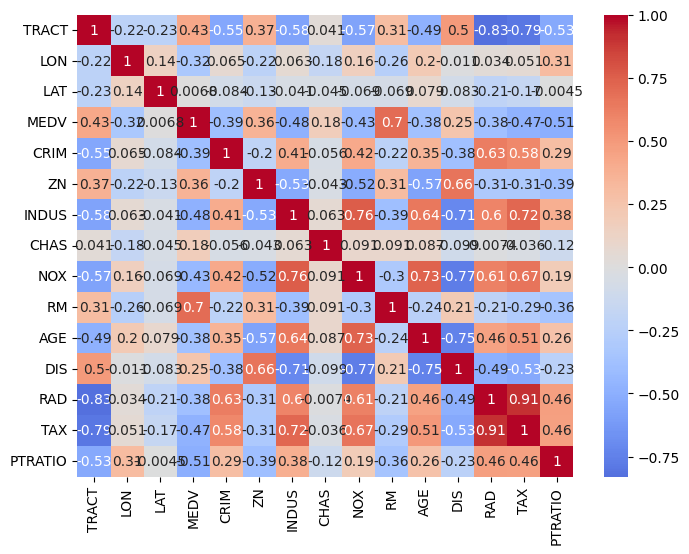

In [ ]:
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

In [ ]:
X=housing_dataset.drop(['MEDV'], axis=1)
y=housing_dataset.filter(['MEDV'], axis=1)

In [ ]:
X.head()

,TRACT,LON,LAT,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO
0,2011,-70.955,42.2550,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3
1,2021,-70.950,42.2875,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8
2,2022,-70.936,42.2830,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8
3,2031,-70.928,42.2930,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7
4,2032,-70.922,42.2980,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7


In [ ]:
y.head()

,MEDV
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
house_predictor=LinearRegression()
house_predictor.fit(X_train, y_train)
y_pred = house_predictor.predict(X_test)

In [ ]:
print('Error Medio Absoluto - Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Error Cuadrático Medio - Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Error Medio Absoluto - Mean Absolute Error (MAE): 3.399704535554148
Error Cuadrático Medio - Mean Squared Error (MSE): 28.9936897024914
Root Mean Squared Error: 5.38457887884386


El valor MAE (Error Medio Absoluto) muestra que, por término medio, hay un error de 3,X dólares entre los valores reales y los previstos para la columna MEDV.

EL Error Cuadrático Medio (MSE) es una de las funciones de pérdida de regresión más comunes. En el error cuadrático medio, también conocido como pérdida L2, calculamos el error elevando al cuadrado la diferencia entre el valor predicho y el valor real y promediando el conjunto de datos.   
Representa la distancia al cuadrado entre los valores reales y predichos. Se eleva al cuadrado para evitar la cancelación de términos negativos.   


### <a id='toc1_4_1_'></a>[Análisis evaluativo del modelo](#toc0_)

- Mean Absolute Error (MAE) ≈ 3.40
Esto indica que, en promedio, la predicción se desvía 3.40 miles de dólares (es decir, $3,400) del valor real.
- Mean Squared Error (MSE) ≈ 28.99 y Root Mean Squared Error (RMSE) ≈ 5.38
El RMSE indica que, en promedio, el error de predicción es de 5.38 miles de dólares (unos $5,380).   

Que el RMSE sea mayor que el MAE (5.38 vs 3.40) sugiere que existen algunos casos con errores más grandes que elevan el promedio cuadrático. (posible existencia de Outliers!?)

## <a id='toc1_5_'></a>[EJERCICIO PRÁCTICO](#toc0_)

Usando el dataset **"diamonds"**, con información sobre diamantes y que viene en el paquete Seaborn. El objetivo del ejercicio es predecir el precio de un diamante ("price") en función de los quilates de este ("carat").

### PASO 1 - Carga del dataset (mediante url) y conversión en DataFrame

Carga de librerías necesarias.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Cargamos los datos en un DataFrame

In [33]:
df_diamonds = sns.load_dataset('diamonds')
df_diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


A partir de aquí, realiza el análisis, la construción y entrenamiento del modelo y, por último, la evaluación del mismo.

In [34]:
df_diamonds.shape

(53940, 10)

In [35]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [36]:
df_diamonds.drop(['cut', 'color', 'clarity', 'depth', 'table'], axis='columns', inplace=True)

In [37]:
df_diamonds.head()

,carat,price,x,y,z
0,0.23,326,3.95,3.98,2.43
1,0.21,326,3.89,3.84,2.31
2,0.23,327,4.05,4.07,2.31
3,0.29,334,4.20,4.23,2.63
4,0.31,335,4.34,4.35,2.75


In [38]:
plt.rcParams["figure.figsize"] = (8, 6)
corr = df_diamonds.corr()
corr

,carat,price,x,y,z
carat,1.000000,0.921591,0.975094,0.951722,0.953387
price,0.921591,1.000000,0.884435,0.865421,0.861249
x,0.975094,0.884435,1.000000,0.974701,0.970772
y,0.951722,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.861249,0.970772,0.952006,1.000000


<Axes: >

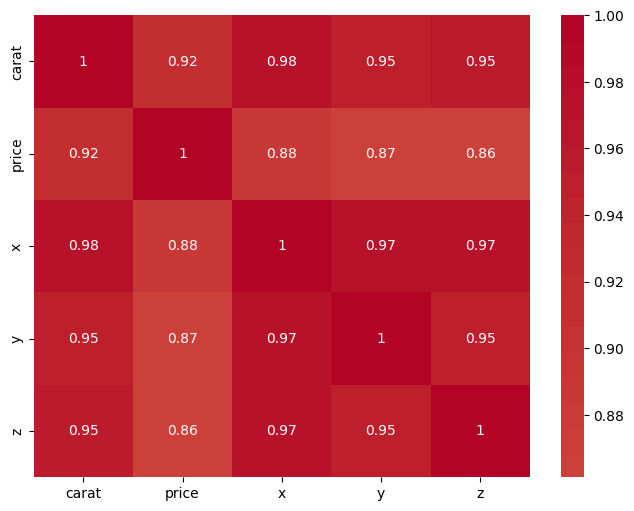

In [39]:
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

In [40]:
X=df_diamonds.drop(['price'], axis=1)
y=df_diamonds.filter(['price'], axis=1)

In [41]:
X.head()

,carat,x,y,z
0,0.23,3.95,3.98,2.43
1,0.21,3.89,3.84,2.31
2,0.23,4.05,4.07,2.31
3,0.29,4.20,4.23,2.63
4,0.31,4.34,4.35,2.75


In [42]:
y.head()

,price
0,326
1,326
2,327
3,334
4,335


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
diamonds_predictor=LinearRegression()
diamonds_predictor.fit(X_train, y_train)
y_pred = diamonds_predictor.predict(X_test)

In [45]:
import numpy as np
from sklearn import metrics
print('Error Medio Absoluto - Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Error Cuadrático Medio - Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Error Medio Absoluto - Mean Absolute Error (MAE): 908.341285319409
Error Cuadrático Medio - Mean Squared Error (MSE): 2315903.688072045
Root Mean Squared Error: 1521.809346821094
